In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from NN_Utils import TimeSeriesRandomSearch, make_build_model
from Utils import plot_performance_analysis
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score

In [2]:
X = pd.read_csv('./dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
y_columns = [f'V{i}' for i in range(2,15)] + ['PERD', 'QGEN7'] #V1 ES SIEMPRE 1.0 EN DATASET
Y = pd.read_csv('./dataset/dataset_out.txt', index_col=0).loc[:, y_columns]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]

In [3]:
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

In [4]:
input_dim = x_train.shape[1]
num_volts = len([c for c in y_train.columns if c.startswith('V')])
normalizer_layer = tf.keras.layers.Normalization(axis=-1)
normalizer_layer.adapt(x_train.values)
builder_function = make_build_model(input_dim, num_volts, normalizer_layer)

y_train_qgen = y_train[['QGEN7']]
y_train_perd = y_train[['PERD']]
y_train_volt = y_train.drop(columns=['QGEN7', 'PERD'])

tuner = TimeSeriesRandomSearch(builder_function, objective='val_loss', max_trials=10, overwrite=True, project_name='nn_random_search', seed=42)

In [7]:
tuner.search(
    x_train,
    y={
        'out_volt': y_train_volt,
        'out_perd': y_train_perd,
        'out_qgen7': y_train_qgen,
    },
    epochs=10,
    batch_size=32
)

Trial 10 Complete [00h 03m 06s]
val_loss: 0.012182138860225677

Best val_loss So Far: 0.009671695064753294
Total elapsed time: 00h 21m 36s


In [8]:
best_random_model = tuner.oracle.get_best_trials(1)[0]
for metric_name in best_random_model.metrics.metrics.keys():
    val = best_random_model.metrics.get_best_value(metric_name)
    print(f"{metric_name}: {val:.5f}")

val_loss: 0.00967
val_out_perd_loss: 0.00065
val_out_perd_mae: 0.01430
val_out_perd_mape: 7.81327
val_out_perd_r2_score: 0.97617
val_out_qgen7_loss: 0.00760
val_out_qgen7_mae: 0.04915
val_out_qgen7_mape: 8.41785
val_out_qgen7_r2_score: 0.80343
val_out_volt_loss: 0.00076
val_out_volt_mae: 0.02085
val_out_volt_mape: 177.17271
val_out_volt_r2_score: 0.96477


In [9]:
best_random_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = builder_function(best_random_hp)
normalizer_qgen = MinMaxScaler(feature_range=(0, 1))
normalizer_volts = MinMaxScaler(feature_range=(0, 1))
normalizer_perd = MinMaxScaler(feature_range=(0, 1))
y_train_qgen_norm = normalizer_qgen.fit_transform(y_train_qgen)
y_train_perd_norm = normalizer_perd.fit_transform(y_train_perd)
y_train_volt_norm = normalizer_volts.fit_transform(y_train_volt)

In [10]:
results = best_model.fit(
    x_train,
    {
        'out_qgen7': y_train_qgen_norm,
        'out_volt': y_train_volt_norm,
        'out_perd': y_train_perd_norm
    },
    epochs=20,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

Epoch 1/20
2230/2230 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0418 - out_perd_loss: 0.0016 - out_perd_mae: 0.0276 - out_perd_mape: 480.0165 - out_perd_r2_score: 0.7952 - out_qgen7_loss: 0.0208 - out_qgen7_mae: 0.0949 - out_qgen7_mape: 11692.5508 - out_qgen7_r2_score: 0.4592 - out_volt_loss: 0.0179 - out_volt_mae: 0.0713 - out_volt_mape: 2231.9976 - out_volt_r2_score: -0.1693 - val_loss: 0.0263 - val_out_perd_loss: 0.0066 - val_out_perd_mae: 0.0661 - val_out_perd_mape: 74.8121 - val_out_perd_r2_score: 0.1320 - val_out_qgen7_loss: 0.0111 - val_out_qgen7_mae: 0.0725 - val_out_qgen7_mape: 12.2199 - val_out_qgen7_r2_score: 0.7144 - val_out_volt_loss: 0.0019 - val_out_volt_mae: 0.0340 - val_out_volt_mape: 6.4038 - val_out_volt_r2_score: 0.8770
Epoch 2/20
2230/2230 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0124 - out_perd_loss: 5.8567e-04 - out_perd_mae: 0.0180 - out_perd_mape: 21.8929 - out_perd_r2_score: 0.9227 - out_qgen7_loss: 0.0098 - out_qgen7_mae: 0.0634 - out_qgen7_mape: 11928.2969

In [31]:
best_model.save('./models/MO_NeuralNetwork.keras')

In [20]:
predictions = best_model.predict(x_test)
pred_volts_norm = predictions[0]
pred_perd_norm = predictions[1]
pred_qgen_norm = predictions[2]
y_pred_volts = normalizer_volts.inverse_transform(pred_volts_norm)
y_pred_perd = normalizer_perd.inverse_transform(pred_perd_norm)
y_pred_qgen = normalizer_qgen.inverse_transform(pred_qgen_norm)
y_pred = pd.DataFrame(np.hstack([y_pred_volts, y_pred_perd, y_pred_qgen]), columns=y_test.columns, index=y_test.index)

656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step


In [25]:
evaluate_MAE = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
evaluate_MAPE = mean_absolute_percentage_error(y_test + 1.0, y_pred + 1.0, multioutput='raw_values')
evaluate_R2 = r2_score(y_test, y_pred, multioutput='raw_values')
evaluate_data_score = np.vstack([evaluate_MAE, evaluate_MAPE, evaluate_R2])
pd.DataFrame(evaluate_data_score, columns=y_columns, index=['MAE', 'MAPE', 'R2'])

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001761,0.001791,0.001770,0.001755,0.001763,0.001778,0.001777,0.001784,0.001758,0.001763,0.001776,0.001329,0.001220,0.129356,0.009228
MAPE,0.000893,0.000908,0.000898,0.000890,0.000894,0.000902,0.000901,0.000905,0.000891,0.000894,0.000900,0.000671,0.000616,0.015186,0.008683
R2,0.972186,0.971767,0.972406,0.973017,0.972738,0.972369,0.972388,0.972084,0.972875,0.972670,0.972434,0.980803,0.983291,0.983574,0.855586


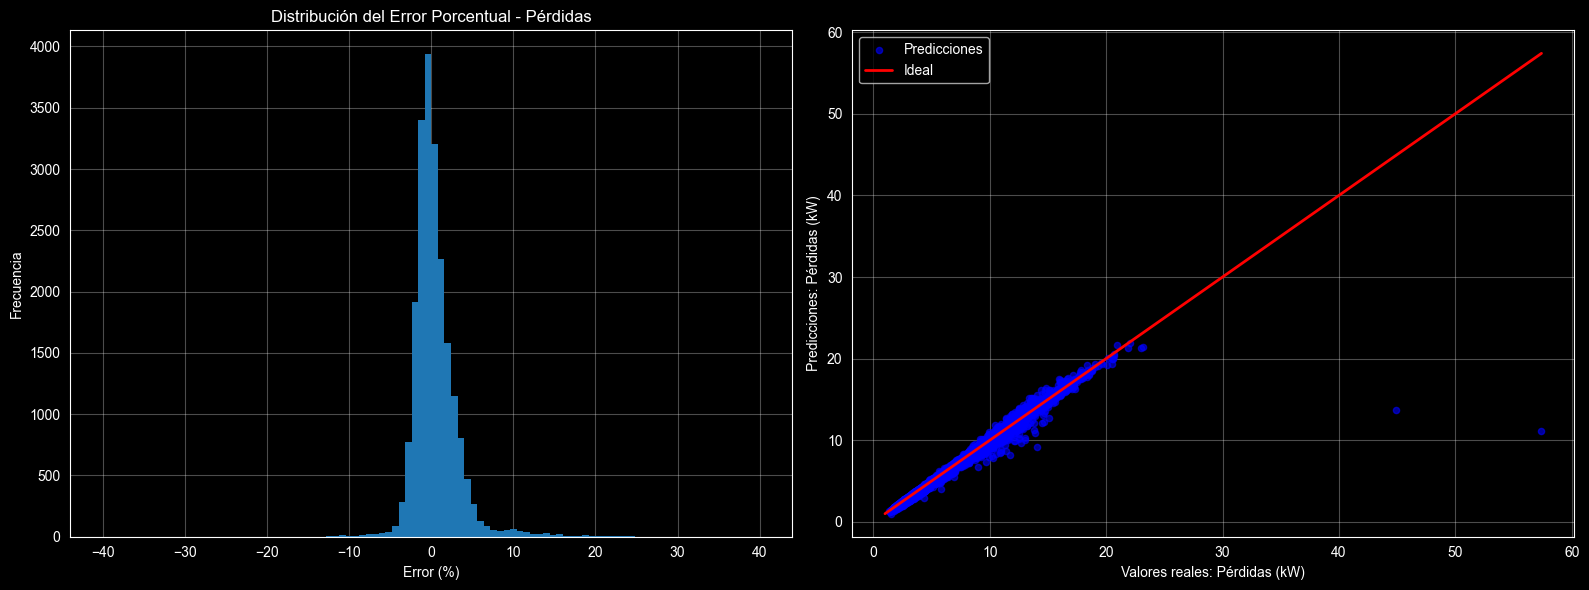

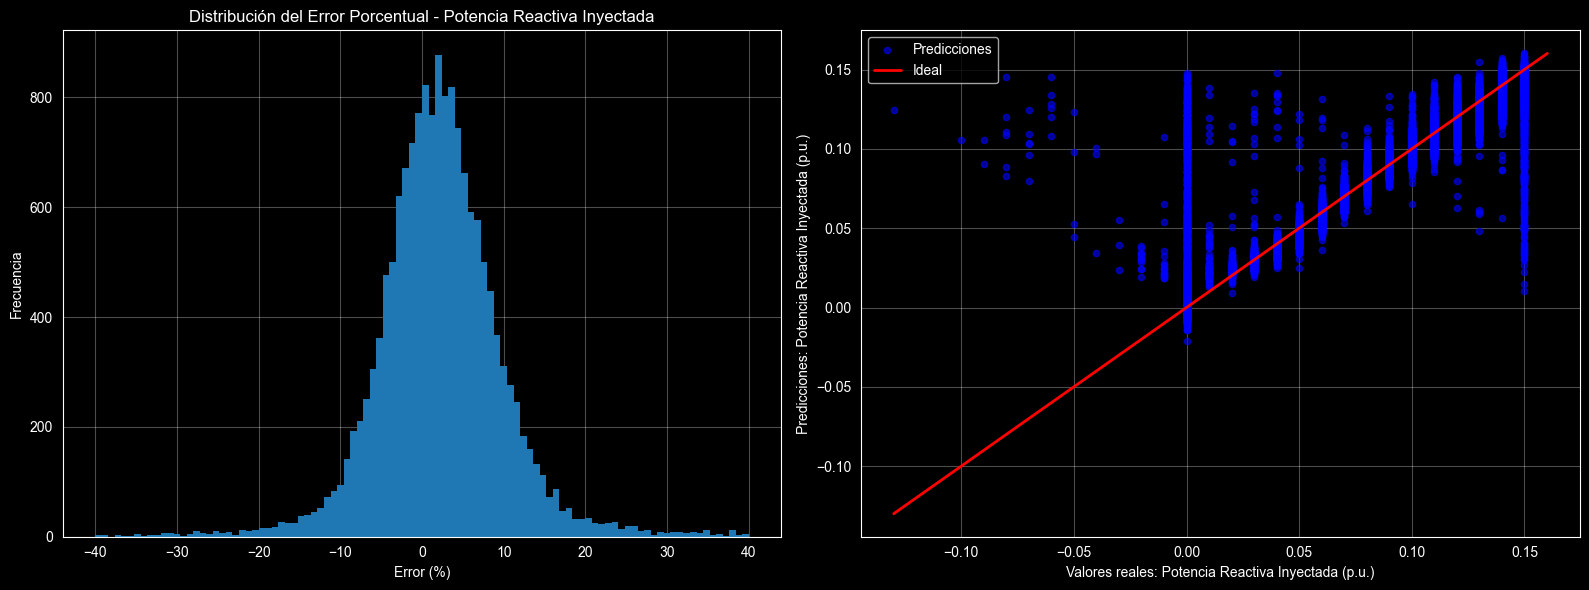

In [30]:
plot_performance_analysis(
    y_test['PERD'],
    y_pred.iloc[:, -2],
    variable_name="Pérdidas",
    unit_label="kW"
)

plot_performance_analysis(
    y_test['QGEN7'],
    y_pred.iloc[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u."
)